Using device: cuda


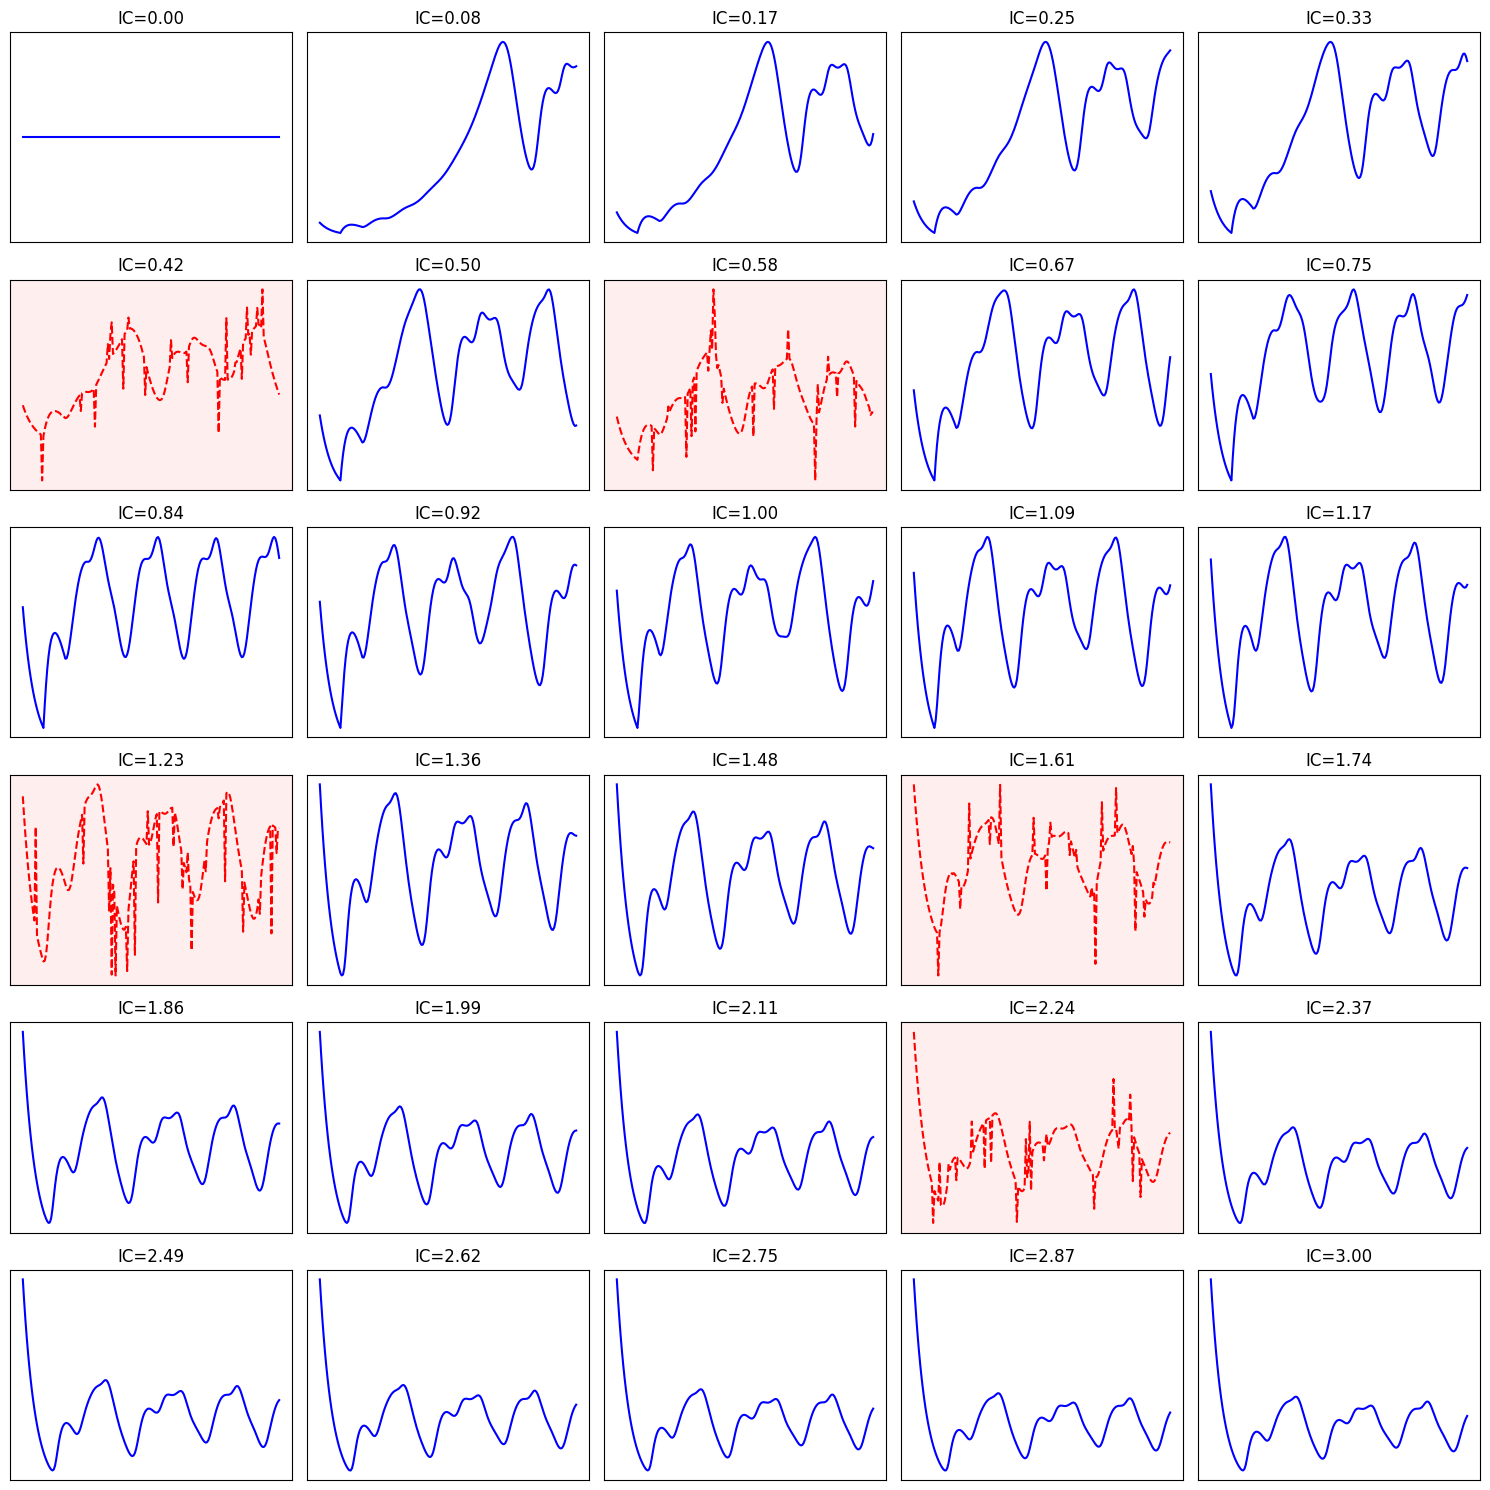

Epoch 000 | Train: 3.3468e+00 | Val: 1.3705e-01
Epoch 001 | Train: 1.2296e+00 | Val: 8.6038e-02
Epoch 002 | Train: 9.8761e-01 | Val: 9.3600e-02
Epoch 003 | Train: 9.8679e-01 | Val: 8.5276e-02
Epoch 004 | Train: 9.2200e-01 | Val: 8.5818e-02
Epoch 005 | Train: 8.9607e-01 | Val: 8.2071e-02
Epoch 006 | Train: 9.0070e-01 | Val: 7.7235e-02
Epoch 007 | Train: 8.7872e-01 | Val: 6.8577e-02
Epoch 008 | Train: 8.6991e-01 | Val: 6.0571e-02
Epoch 009 | Train: 8.8662e-01 | Val: 6.4368e-02
Epoch 010 | Train: 7.8500e-01 | Val: 5.0044e-02
Epoch 011 | Train: 8.4921e-01 | Val: 5.0695e-02
Epoch 012 | Train: 8.1136e-01 | Val: 4.5218e-02
Epoch 013 | Train: 7.3504e-01 | Val: 4.4284e-02
Epoch 014 | Train: 7.7242e-01 | Val: 4.3884e-02
Epoch 015 | Train: 7.1876e-01 | Val: 5.5401e-02
Epoch 016 | Train: 7.0471e-01 | Val: 5.1337e-02
Epoch 017 | Train: 6.6187e-01 | Val: 5.3957e-02
Epoch 018 | Train: 6.3632e-01 | Val: 5.7206e-02
Epoch 019 | Train: 6.2460e-01 | Val: 5.2104e-02
Epoch 020 | Train: 5.8828e-01 | Val: 4.7

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.stats import f as f_dist
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import time
import random
import os
import psutil

# --- 1. Fix Python, NumPy, and random seeds ---
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# ===============================
# 2. Utility: Resource Tracking
# ===============================
def get_cpu_memory_mb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**2

def get_gpu_memory_mb():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        return torch.cuda.max_memory_allocated() / 1024**2
    return None

# --- 2. Force deterministic behavior for cuDNN ---
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Use GPU if available ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# --- Mackey-Glass Generator ---
def mackey_glass(t_max, tau=17, delta_t=1, beta=0.2, gamma=0.1, n=10, x0=1.2):
    t_len = int(t_max / delta_t)
    x = np.zeros(t_len)
    x[0] = x0
    for t in range(1, t_len):
        if t - tau >= 0:
            x[t] = x[t - 1] + delta_t * (
                beta * x[t - tau] / (1 + x[t - tau] ** n) - gamma * x[t - 1]
            )
        else:
            x[t] = x[t - 1] - delta_t * gamma * x[t - 1]
    return x
# --- Function to insert anomalies ---
def insert_anomalies(x, anomaly_rate=0.05, anomaly_scale=0.5):
    """
    Insert anomalies into a time series.
    anomaly_rate: fraction of points that are anomalous
    anomaly_scale: magnitude of anomalies
    """
    x_anom = x.copy()
    n_points = len(x)
    n_anomalies = int(n_points * anomaly_rate)

    anomaly_indices = np.random.choice(n_points, size=n_anomalies, replace=False)
    for idx in anomaly_indices:
        x_anom[idx] += np.random.uniform(-anomaly_scale, anomaly_scale)
    return x_anom

# --- Parameters ---
t_max = 200
delta_t = 1
train_ics_left = np.linspace(0, 1.17, 15)
train_ics_right = np.linspace(1.23, 3, 15)
train_ics = np.concatenate((train_ics_left, train_ics_right))
test_ic = 1.6
timesteps = np.arange(0, t_max, delta_t)

# --- Generate training data (with anomalies on 5 sequences) ---
X_list, y_list = [], []
rng = np.random.default_rng()  # independent generator (no fixed seed)
anomalous_indices = [15, 5, 23, 7, 18]

for i, ic in enumerate(train_ics):
    x = mackey_glass(t_max=t_max, x0=ic)
    if i in anomalous_indices:
        x = insert_anomalies(x, anomaly_rate=0.1, anomaly_scale=0.7)  # insert anomalies
    norm_t = timesteps / t_max
    features = np.stack([np.full_like(norm_t, ic), norm_t], axis=1)
    X_list.append(features)
    y_list.append(x)

X = np.vstack(X_list)
y = np.concatenate(y_list)

import math

# Number of rows and columns for subplot grid
n_traj = len(y_list)
n_cols = 5  # you can change this
n_rows = math.ceil(n_traj / n_cols)

plt.figure(figsize=(n_cols*3, n_rows*2.5))

for i, x in enumerate(y_list):
    plt.subplot(n_rows, n_cols, i+1)
    if i in anomalous_indices:
        plt.plot(x, 'r--', label=f"IC={train_ics[i]:.2f} (Anomalous)")
    else:
        plt.plot(x, 'b-', label=f"IC={train_ics[i]:.2f}")
    plt.title(f"IC={train_ics[i]:.2f}")
    plt.xticks([])
    plt.yticks([])
    if i in anomalous_indices:
        plt.gca().set_facecolor("#ffeeee")  # light red background for anomalies

plt.tight_layout()
plt.show()

# --- Generate test data ---
x_test = mackey_glass(t_max=200, x0=test_ic)
norm_t_test = timesteps / t_max
X_test = np.stack([np.full_like(norm_t_test, test_ic), norm_t_test], axis=1)
y_test = x_test

# --- Normalize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# --- Prepare torch datasets ---
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).reshape(len(train_ics), t_max, 2)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(len(train_ics), t_max)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(0).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(0).to(device)

# Split into train and validation (36 train, 4 val)
val_split = 1
train_len = len(train_ics) - val_split
train_dataset, val_dataset = random_split(TensorDataset(X_tensor, y_tensor), [train_len, val_split])
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)
# --- GRU Model ---
class GRUNet(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=3):
        super(GRUNet, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.linear(out).squeeze(-1)
        return out
model = GRUNet().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# --- Early stopping params ---
best_val_loss = float('inf')
patience = 40
patience_counter = 0
best_model_state = None
# --- Train with validation tracking ---
train_losses = []
val_losses = []

# --- Train the model ---
epochs = 200
cpu_mem_log = []
gpu_mem_log = []
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation loss
    model.eval()
    with torch.no_grad():
        val_loss = 0
        for xb_val, yb_val in val_loader:
            xb_val, yb_val = xb_val.to(device), yb_val.to(device)
            val_output = model(xb_val)
            val_loss += criterion(val_output, yb_val).item()
        val_loss /= len(val_loader)
    gpu_mem_log.append(get_gpu_memory_mb())
    cpu_mem_log.append(get_cpu_memory_mb())
    if torch.cuda.is_available():
        gpu_mem_log.append(get_gpu_memory_mb())

    print(f"Epoch {epoch:03d} | Train: {total_loss:.4e} | Val: {val_loss:.4e}")
    train_losses.append(total_loss)
    val_losses.append(val_loss)

    # Check early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break


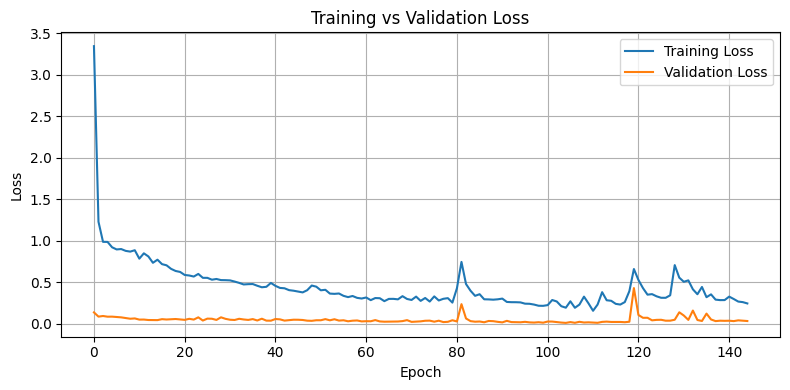


Test RMSE: 0.1466
Test R²:   0.7114


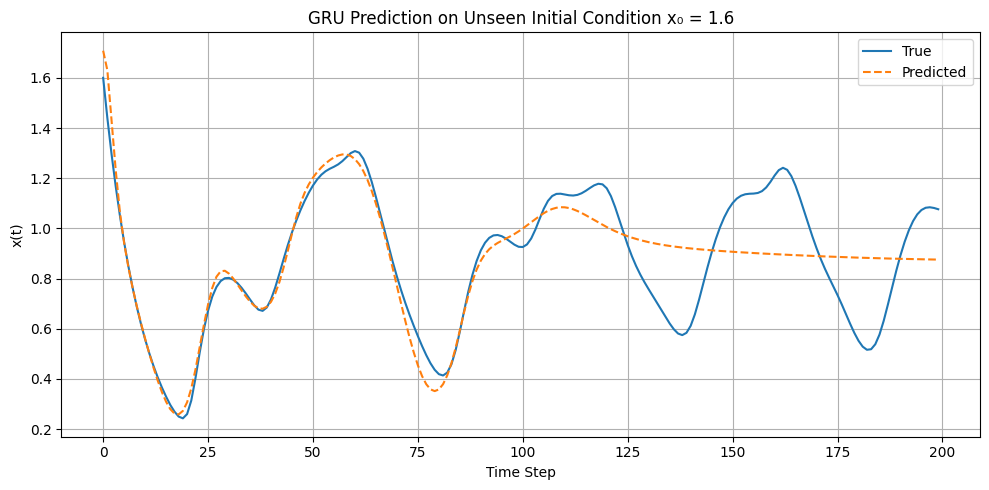

F-statistic: 242.8188
P-value:     1.1102e-16
Total Runtime: 0.00 seconds


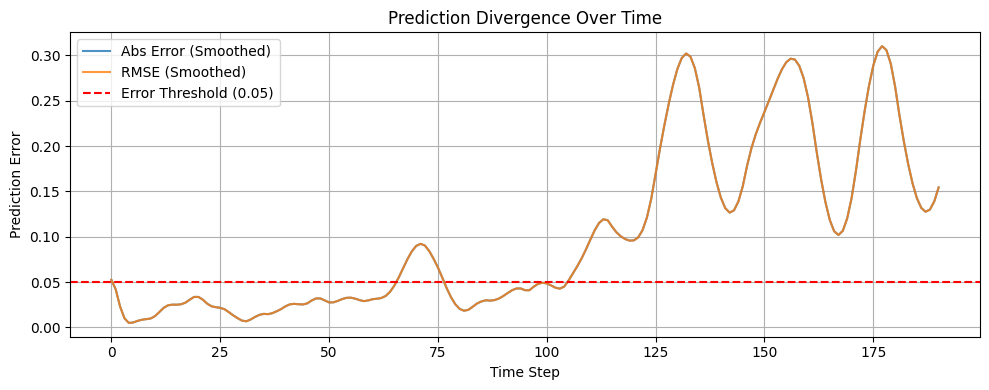

Prediction horizon (persistent divergence): 66 steps


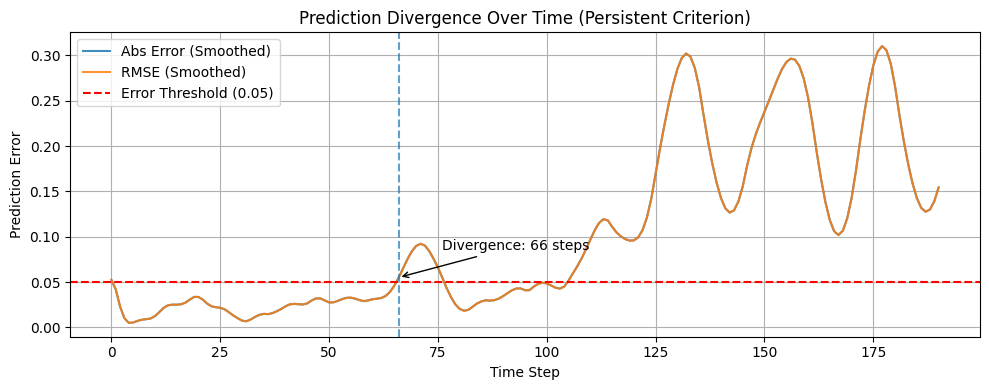

In [8]:
# --- Plot Training vs Validation Loss ---
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Load best model ---
start_time = time.time()
# --- Predict on test IC ---
model.eval()
with torch.no_grad():
    pred_test = model(X_test_tensor).squeeze(0).cpu().numpy()

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2 = r2_score(y_test, pred_test)
print(f"\nTest RMSE: {rmse:.4f}")
print(f"Test R²:   {r2:.4f}")
end_time = time.time()
# --- Plot results ---
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='True')
plt.plot(pred_test, label='Predicted', linestyle='--')
plt.title(f"GRU Prediction on Unseen Initial Condition x₀ = {test_ic}")
plt.xlabel("Time Step")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- F-statistic and p-value ---
n = len(y_test)
k = X_test.shape[1]  # number of predictors = 2
F_stat = (r2 / k) / ((1 - r2) / (n - k - 1))
p_value = 1 - f_dist.cdf(F_stat, k, n - k - 1)

print(f"F-statistic: {F_stat:.4f}")
print(f"P-value:     {p_value:.4e}")

print(f"Total Runtime: {end_time - start_time:.2f} seconds")

import numpy as np
import matplotlib.pyplot as plt

# Divergence
errors = np.abs(pred_test - y_test)            # abs error
rmse_window = np.sqrt((pred_test - y_test)**2) # RMSE error

# Optional: smooth with moving average for clarity
def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

window_size = 10
smoothed_error = moving_avg(errors, w=window_size)
smoothed_rmse = moving_avg(rmse_window, w=window_size)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(smoothed_error, label="Abs Error (Smoothed)", alpha=0.8)
plt.plot(smoothed_rmse, label="RMSE (Smoothed)", alpha=0.8)
plt.axhline(y=0.05, color='r', linestyle='--', label='Error Threshold (0.05)')
plt.title("Prediction Divergence Over Time")
plt.xlabel("Time Step")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Divergence
import numpy as np
import matplotlib.pyplot as plt

np.save("train_losses.npy", train_losses)
np.save("val_losses.npy", val_losses)

errors = np.abs(pred_test - y_test)
rmse = np.sqrt((pred_test - y_test) ** 2)

def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w) / w, mode="valid")

window_size = 10
smoothed_error = moving_avg(errors, w=window_size)
smoothed_rmse = moving_avg(rmse, w=window_size)

threshold = 0.05
patience = 10

above = smoothed_error > threshold
divergence_time = None

for t in range(len(above) - patience):
    if above[t] and np.all(above[t:t + patience]):
        divergence_time = t
        break

if divergence_time is None:
    print(f"No persistent divergence detected (threshold={threshold}, patience={patience})")
else:
    print(f"Prediction horizon (persistent divergence): {divergence_time} steps")

plt.figure(figsize=(10, 4))
plt.plot(smoothed_error, label="Abs Error (Smoothed)", alpha=0.85)
plt.plot(smoothed_rmse, label="RMSE (Smoothed)", alpha=0.85)
plt.axhline(y=threshold, color="r", linestyle="--", label=f"Error Threshold ({threshold})")

if divergence_time is not None:
    plt.axvline(divergence_time, linestyle="--", alpha=0.7)

    x_min, x_max = 0, len(smoothed_error)
    y_min, y_max = 0, max(smoothed_error) * 1.1

    x_text = divergence_time + 10
    if x_text > x_max - 20:
        x_text = divergence_time - 20
    x_text = np.clip(x_text, x_min, x_max)

    y_text = smoothed_error[divergence_time] + 0.03
    y_text = np.clip(y_text, y_min, y_max)

    plt.annotate(
        f"Divergence: {divergence_time} steps",
        xy=(divergence_time, smoothed_error[divergence_time]),
        xytext=(x_text, y_text),
        arrowprops=dict(arrowstyle="->"),
        fontsize=10
    )

plt.title("Prediction Divergence Over Time (Persistent Criterion)")
plt.xlabel("Time Step")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
from scipy.stats import pearsonr, spearmanr

def correlation_metrics(y_true, y_pred):
    pearson_corr, _ = pearsonr(y_true, y_pred)
    spearman_corr, _ = spearmanr(y_true, y_pred)
    return pearson_corr, spearman_corr

pearson_corr, spearman_corr = correlation_metrics(y_test, pred_test)
print(f"Pearson correlation: {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")

Pearson correlation: 0.8449
Spearman correlation: 0.7647


Spectral cosine similarity: 0.9927


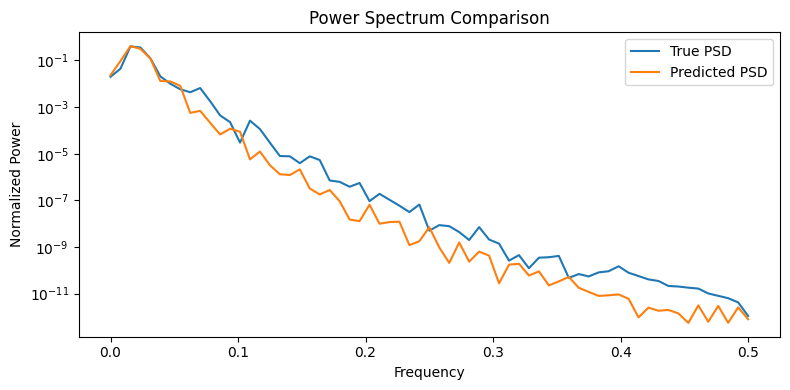

In [10]:
from scipy.signal import welch
from numpy.linalg import norm

def spectral_similarity(y_true, y_pred, fs=1.0):
    # Welch’s method for power spectral density (PSD)
    f_true, Pxx_true = welch(y_true, fs=fs, nperseg=128)
    f_pred, Pxx_pred = welch(y_pred, fs=fs, nperseg=128)

    # Normalize
    Pxx_true /= np.sum(Pxx_true)
    Pxx_pred /= np.sum(Pxx_pred)

    # Cosine similarity
    cosine_sim = np.dot(Pxx_true, Pxx_pred) / (norm(Pxx_true) * norm(Pxx_pred))
    return cosine_sim, f_true, Pxx_true, Pxx_pred

cos_sim, f, spec_true, spec_pred = spectral_similarity(y_test, pred_test)
print(f"Spectral cosine similarity: {cos_sim:.4f}")

# Plot spectra
plt.figure(figsize=(8,4))
plt.semilogy(f, spec_true, label="True PSD")
plt.semilogy(f, spec_pred, label="Predicted PSD")
plt.title("Power Spectrum Comparison")
plt.xlabel("Frequency")
plt.ylabel("Normalized Power")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
cpuMemory = np.array(cpu_mem_log)
print(f"CPU RAM used: {np.mean(cpuMemory):.2f} MB")
gpuMemory = np.array(gpu_mem_log)
print(f"Peak GPU memory: {np.mean(gpuMemory):.2f} MB")

CPU RAM used: 1207.78 MB
Peak GPU memory: 49.56 MB
